In [1]:
from tensorflow.keras.datasets import mnist
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Load the dataset
(X_train, y_train), (X_test,y_test) = mnist.load_data()

# Display dataset shapes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


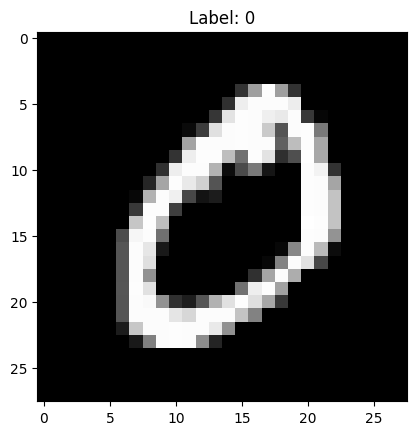

In [4]:
# Basic Data Visualisation
img = X_train[1,:,:]
label = y_train[1]
plt.imshow(img,cmap='gray')
plt.title(f"Label: {label}")
plt.show()

### Data Preprocessing
Normalize the data and reshape it for CNN input


In [5]:
# Normalize and reshape
X_train = X_train.reshape(-1,28,28,1).astype('float32')/255
X_test = X_test.reshape(-1,28,28,1).astype('float32')/255

# One-hot Label Encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

### Model Building
Build a CNN model using Keras Sequential API.

In [8]:
model = Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)), # Convolutional layer -> detects patterns
    MaxPooling2D(pool_size=(2,2)), # Pooling layer -> reduces spatial dimensions
    Conv2D(64,kernel_size=(3,3),activation='relu'), #Convolutional layer -> detects patterns
    MaxPooling2D(pool_size=(2,2)), # Pooling layer -> reduces spatial dimensions
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation
Compile the model with Adam optimizer and categorical crossentropy loss.

In [10]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

### Model Training
Train the model on the training data

In [12]:
history =model.fit(X_train, y_train, epochs = 5, batch_size=128, validation_split=0.2)
# epochs -> Model sees dataset 5 times
# Batch_size = Processes 128 images per step
# Validation_split -> Use 20%

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8400 - loss: 0.5432 - val_accuracy: 0.9769 - val_loss: 0.0832
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9779 - loss: 0.0723 - val_accuracy: 0.9823 - val_loss: 0.0590
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9850 - loss: 0.0455 - val_accuracy: 0.9820 - val_loss: 0.0558
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9892 - loss: 0.0345 - val_accuracy: 0.9877 - val_loss: 0.0436
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9922 - loss: 0.0264 - val_accuracy: 0.9878 - val_loss: 0.0396


### Model Evaluation
Evaluate the model on test data

In [16]:
test_loss, test_accuracy = model.evaluate(X_test,y_test)
print(f"Test Loss:{test_loss}")
print(f"Test Accuracy:{test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9848 - loss: 0.0426
Test Loss:0.033834345638751984
Test Accuracy:0.9884999990463257


### Prediction
Make predictions on new data samples

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


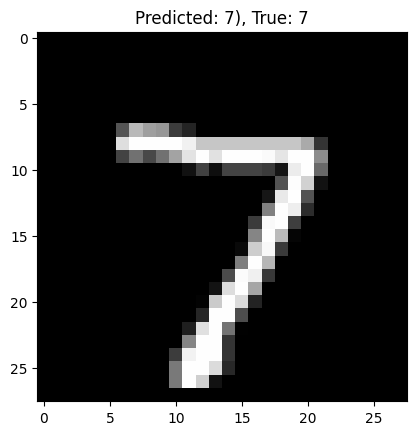

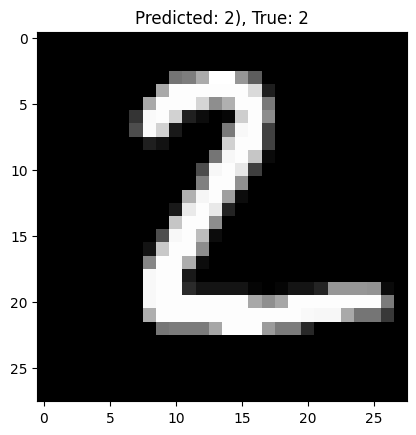

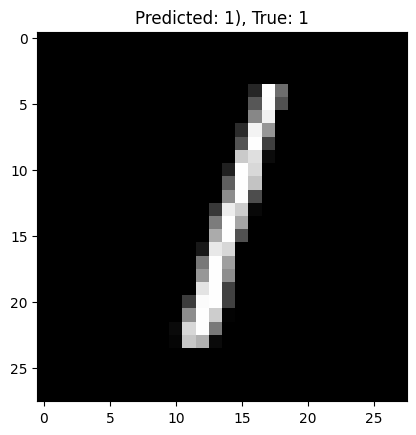

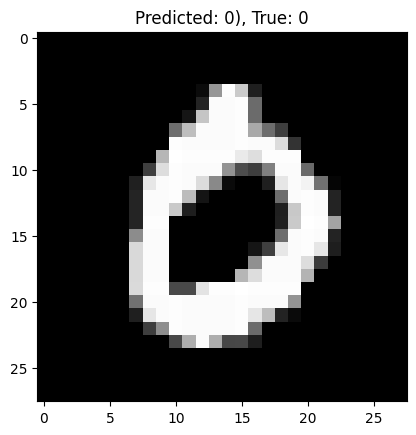

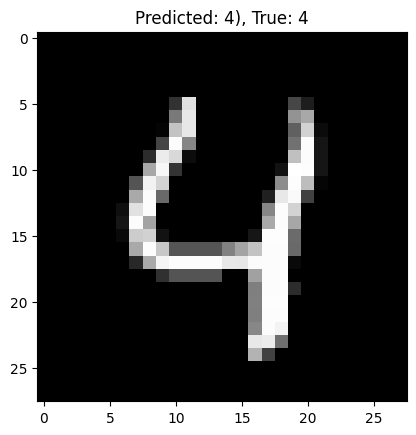

In [17]:
# Predict on the few test samples
predictions = model.predict(X_test[:5])
predicted_classes = np.argmax(predictions,axis=1)
true_classes=np.argmax(y_test[:5],axis=1)

for i in range(5):
  plt.imshow(X_test[i].reshape(28,28),cmap='gray')
  plt.title(f"Predicted: {predicted_classes[i]}), True: {true_classes[i]}")
  plt.show()